Text(0.5, 1.0, 'Exponential(2)+-1/2 samples')

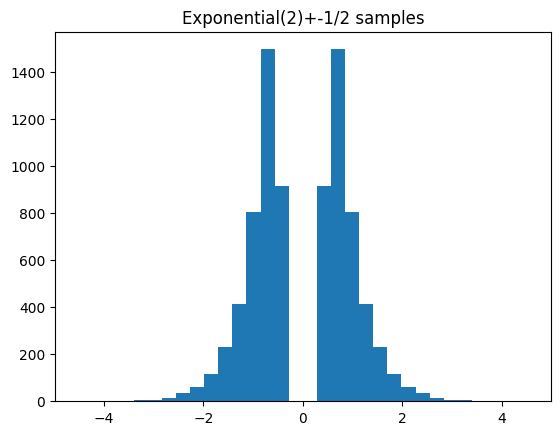

In [17]:

from matplotlib import pyplot as plt
import torch
true_dist = torch.distributions.Exponential(2)

x = true_dist.sample((4096,1))
x=torch.concat([x+1/2,-x-1/2],0)

x-=x.mean()
x/=x.std()

plt.hist(x,bins=32)
plt.title("Exponential(2)+-1/2 samples")

In [18]:
from kemsekov_torch.flow_matching import FlowModel1d
m = FlowModel1d(1)
with torch.no_grad():
    print(m.log_prob(x).mean())
m.fit(x,epochs=64)
with torch.no_grad():
    print(m.log_prob(x).mean())
m.time_scaler

tensor(-1.8107)
tensor(-1.4579)


Parameter containing:
tensor([10.4685], requires_grad=True)

In [19]:
m.default_steps=32

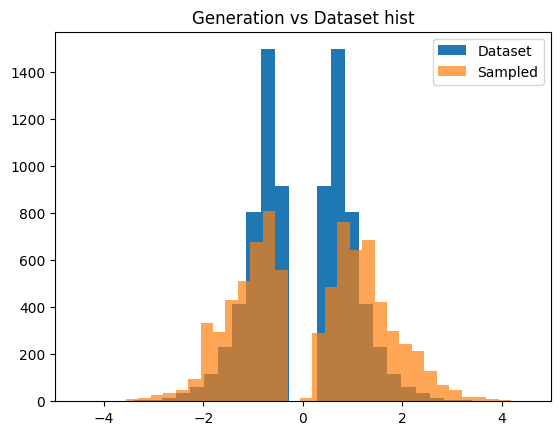

In [20]:
with torch.no_grad():
    sample_x = m.sample(len(x))
bins = 32
plt.hist(x,bins=bins,label='Dataset')
plt.hist(sample_x,alpha=0.7,bins=bins,label='Sampled')
plt.title("Generation vs Dataset hist")
plt.legend()

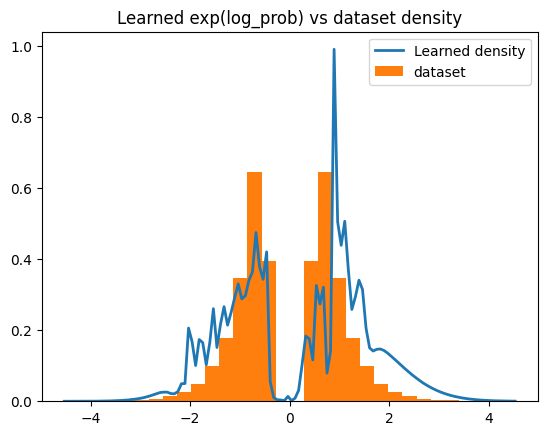

In [21]:
t = torch.linspace(x.min(),x.max(),128)[:,None]
with torch.no_grad():
    logp = m.log_prob(t).exp()
plt.plot(t,logp,label='Learned density',linewidth=2)
plt.hist(x,density=True,bins=bins,label='dataset')
plt.legend()
plt.title("Learned exp(log_prob) vs dataset density")
plt.show()

In [22]:
xin = torch.randn((4096,1))
with torch.no_grad():
    xt,inter = m.to_target(xin,return_intermediates=True,steps=128)

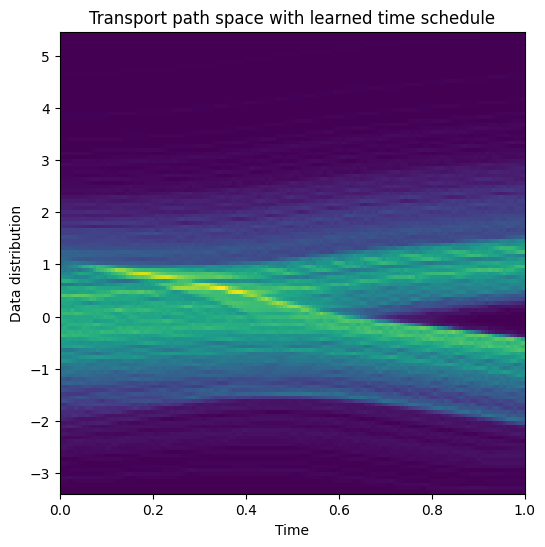

In [23]:
t = torch.linspace(0,1,len(inter))
data = torch.stack(inter)
data_time = data*0+t[:,None,None]
X = data_time.flatten()
Y = data.flatten()
plt.figure(figsize=(6, 6))
plt.hist2d(X, Y, bins=len(inter), cmap='viridis')
plt.xlabel("Time")
plt.ylabel("Data distribution")
plt.title("Transport path space with learned time schedule")
plt.show()

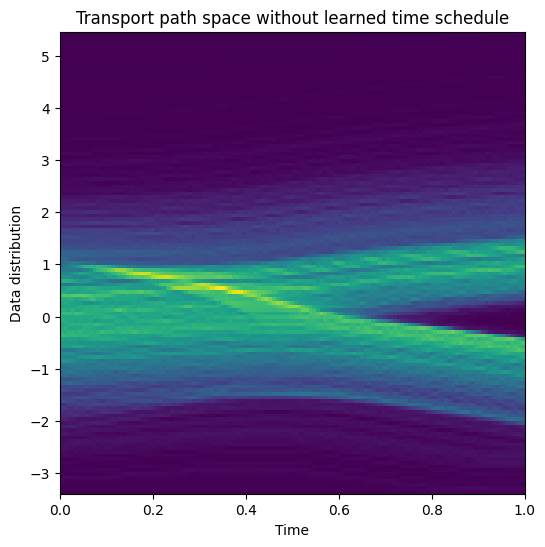

In [24]:
with torch.no_grad():
    m.time_scaler*=0
    m.time_scaler+=1.01
    xt,inter = m.to_target(xin,return_intermediates=True,steps=128)
    
t = torch.linspace(0,1,len(inter))
data = torch.stack(inter)
data_time = data*0+t[:,None,None]
X = data_time.flatten()
Y = data.flatten()
plt.figure(figsize=(6, 6))
plt.hist2d(X, Y, bins=len(inter), cmap='viridis')
plt.xlabel("Time")
plt.ylabel("Data distribution")
plt.title("Transport path space without learned time schedule")
plt.show()